# **TikTok Project**
**Course 5 - The Nuts and bolts of machine learning**

Recall that you are a data professional at TikTok. Your supervisor was impressed with the work you have done and has requested that you **build a machine learning model that can be used to determine whether a video contains a claim or whether it offers an opinion**. With a successful prediction model, TikTok can reduce the backlog of user reports and prioritize them more efficiently.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# **Course 5 End-of-course project: Classifying videos using machine learning**

In this activity, you will practice using machine learning techniques to predict on a binary outcome variable.
<br/>

**The purpose** of this model is to increase response time and system efficiency by automating the initial stages of the claims process.

**The goal** of this model is to predict whether a TikTok video presents a "claim" or presents an "opinion".
<br/>

*This activity has three parts:*

**Part 1:** Ethical considerations
* Consider the ethical implications of the request

* Should the objective of the model be adjusted?

**Part 2:** Feature engineering

* Perform feature selection, extraction, and transformation to prepare the data for modeling

**Part 3:** Modeling

* Build the models, evaluate them, and advise on next steps

Follow the instructions and answer the questions below to complete the activity. Then, you will complete an Executive Summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work.



# **Classify videos using machine learning**

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**


Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## **PACE: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following questions:


1.   **What are you being asked to do? What metric should I use to evaluate success of my business/organizational objective?**

2.   **What are the ethical implications of the model? What are the consequences of your model making errors?**
  *   What is the likely effect of the model when it predicts a false negative (i.e., when the model says a video does not contain a claim and it actually does)?

  *   What is the likely effect of the model when it predicts a false positive (i.e., when the model says a video does contain a claim and it actually does not)?

3.   **How would you proceed?**


1. What are you being asked to do?

Business need and modeling objective

TikTok users can report videos that they believe violate the platform's terms of service. Because there are millions of TikTok videos created and viewed every day, this means that many videos get reported—too many to be individually reviewed by a human moderator.

Analysis indicates that when authors do violate the terms of service, they're much more likely to be presenting a claim than an opinion. Therefore, it is useful to be able to determine which videos make claims and which videos are opinions.

TikTok wants to build a machine learning model to help identify claims and opinions. Videos that are labeled opinions will be less likely to go on to be reviewed by a human moderator. Videos that are labeled as claims will be further sorted by a downstream process to determine whether they should get prioritized for review. For example, perhaps videos that are classified as claims would then be ranked by how many times they were reported, then the top x% would be reviewed by a human each day.

A machine learning model would greatly assist in the effort to present human moderators with videos that are most likely to be in violation of TikTok's terms of service.

**Modeling workflow and model selection process**

Previous work with this data has revealed that there are ~20,000 videos in the sample. This is sufficient to conduct a rigorous model validation workflow, broken into the following steps:

1. Split the data into train/validation/test sets (60/20/20)
2. Fit models and tune hyperparameters on the training set
3. Perform final model selection on the validation set
4. Assess the champion model's performance on the test set

![](https://raw.githubusercontent.com/adacert/tiktok/main/optimal_model_flow_numbered.svg)


### **Task 1. Imports and data loading**

Start by importing packages needed to build machine learning models to achieve the goal of this project.

In [36]:
# Import packages for data manipulation
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for data preprocessing
from sklearn.feature_extraction.text import CountVectorizer

# Import packages for data modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, \
recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance

Now load the data from the provided csv file into a dataframe.

**Note:** As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [38]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

<img src="images/Analyze.png" width="100" height="100" align=left>

## **PACE: Analyze**

Consider the questions in your PACE Strategy Document to reflect on the Analyze stage.

### **Task 2: Examine data, summary info, and descriptive stats**

Inspect the first five rows of the dataframe.

In [44]:
# Display first few rows
### YOUR CODE HERE ###
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Get the number of rows and columns in the dataset.

In [42]:
# Get number of rows and columns
### YOUR CODE HERE ###
data.shape

(19382, 12)

Get the data types of the columns.

In [81]:
# Get data types of columns
### YOUR CODE HERE ###
data.dtypes

#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
text_length                   int64
dtype: object

Get basic information about the dataset.

In [83]:
# Get basic information
### YOUR CODE HERE ###
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19084 entries, 0 to 19083
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19084 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19084 non-null  int64  
 3   video_duration_sec        19084 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19084 non-null  object 
 6   author_ban_status         19084 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
 12  text_length               19084 non-null  int64  
dtypes: float64(5), int64(4), object(4)
memory usage: 2.0+ MB


Generate basic descriptive statistics about the dataset.

In [85]:
# Generate basic descriptive stats
### YOUR CODE HERE ###
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
count,19084.000000,1.908400e+04,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9542.500000,5.624840e+09,32.423811,254708.558688,84304.636030,16735.248323,1049.429627,349.312146,89.093534
std,5509.220604,2.537030e+09,16.226470,322893.280814,133420.546814,32036.174350,2004.299894,799.638865,20.682086
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000,31.000000
25%,4771.750000,3.425100e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000,75.000000
50%,9542.500000,5.609500e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000,87.000000
75%,14313.250000,7.840823e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000,101.000000
max,19084.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000,182.000000


Check for and handle missing values.

In [87]:
# Check for missing values
### YOUR CODE HERE ###
data.isna().sum()

#                           0
claim_status                0
video_id                    0
video_duration_sec          0
video_transcription_text    0
verified_status             0
author_ban_status           0
video_view_count            0
video_like_count            0
video_share_count           0
video_download_count        0
video_comment_count         0
text_length                 0
dtype: int64

In [89]:
# Drop rows with missing values
### YOUR CODE HERE ###
data = data.dropna()

In [91]:

# Display first few rows after handling missing values
### YOUR CODE HERE ###
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128


Check for and handle duplicates.

In [93]:
# Check for duplicates
### YOUR CODE HERE ###
data.duplicated().sum()

0

Check for and handle outliers.

In [94]:
### YOUR CODE HERE ###

# Filter outliers
### YOUR CODE HERE ###
# Identify outliers for all engagement count columns using IQR
count_cols = ['video_view_count', 'video_like_count', 'video_share_count', 'video_download_count', 'video_comment_count']

for col in count_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    outliers = data[(data[col] < (Q1 - 1.5 * IQR)) | (data[col] > (Q3 + 1.5 * IQR))]
    print(f"{col} - Outlier count: {len(outliers)}")

video_view_count - Outlier count: 0
video_like_count - Outlier count: 1726
video_share_count - Outlier count: 2508
video_download_count - Outlier count: 2450
video_comment_count - Outlier count: 2789


Check class balance.

In [95]:
# Check class balance
### YOUR CODE HERE ###
# Check distribution of the claim_status target variable

print(data['claim_status'].value_counts())

claim_status
claim      9608
opinion    9476
Name: count, dtype: int64


<img src="images/Construct.png" width="100" height="100" align=left>

## **PACE: Construct**
Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### **Task 3: Feature engineering**

Extract the length of each `video_transcription_text` and add this as a column to the dataframe, so that it can be used as a potential feature in the model.

In [96]:
# Extract the length of each `video_transcription_text` and add this as a column to the dataframe
### YOUR CODE HERE ###
data['text_length'] = data['video_transcription_text'].str.len()

Calculate the average text_length for claims and opinions.

In [97]:
# Calculate the average text_length for claims and opinions
### YOUR CODE HERE ###
data.groupby('claim_status')['text_length'].mean()

claim_status
claim      95.376978
opinion    82.722562
Name: text_length, dtype: float64

Visualize the distribution of `text_length` for claims and opinions.

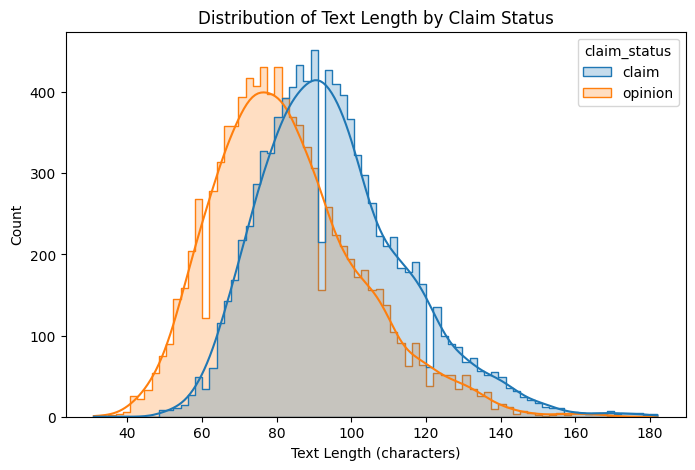

In [98]:
# Visualize the distribution of `text_length` for claims and opinions
# Create two histograms in one plot

### YOUR CODE HERE ###
plt.figure(figsize=(8, 5))

# Plot overlapping histograms for claims and opinions
sns.histplot(
    data=data,
    x='text_length',
    hue='claim_status',
    kde=True,
    element='step'
)

plt.title('Distribution of Text Length by Claim Status')
plt.xlabel('Text Length (characters)')
plt.ylabel('Count')
plt.show()

**Feature selection and transformation**

Encode target and catgorical variables.

In [99]:
# Create a copy of the X data
### YOUR CODE HERE ###
X = data.copy()

### YOUR CODE HERE ###
X = X.drop(['#', 'video_id', 'video_transcription_text'], axis=1)

# Encode target variable (map 'claim' -> 1, 'opinion' -> 0)
### YOUR CODE HERE ###
X['claim_status'] = X['claim_status'].replace({'opinion': 0, 'claim': 1})

# Dummy encode remaining categorical values
### YOUR CODE HERE ###
X = pd.get_dummies(X,
                   columns=['verified_status', 'author_ban_status'],
                   drop_first=True)
X.head()

,claim_status,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,1,59,343296.0,19425.0,241.0,1.0,0.0,97,False,False,True
1,1,32,140877.0,77355.0,19034.0,1161.0,684.0,107,False,False,False
2,1,31,902185.0,97690.0,2858.0,833.0,329.0,137,False,False,False
3,1,25,437506.0,239954.0,34812.0,1234.0,584.0,131,False,False,False
4,1,19,56167.0,34987.0,4110.0,547.0,152.0,128,False,False,False


### **Task 4: Split the data**

Assign target variable.

In [100]:
# Isolate target variable
### YOUR CODE HERE ###
y = X['claim_status']

Isolate the features.

In [101]:
# Isolate features
X = X.drop(['claim_status'], axis=1)

# Display first few rows of features dataframe
X.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,59,343296.0,19425.0,241.0,1.0,0.0,97,False,False,True
1,32,140877.0,77355.0,19034.0,1161.0,684.0,107,False,False,False
2,31,902185.0,97690.0,2858.0,833.0,329.0,137,False,False,False
3,25,437506.0,239954.0,34812.0,1234.0,584.0,131,False,False,False
4,19,56167.0,34987.0,4110.0,547.0,152.0,128,False,False,False


#### **Task 5: Create train/validate/test sets**

Split data into training and testing sets, 80/20.

In [102]:
# Split the data into training and testing sets
### YOUR CODE HERE ###
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Split the training set into training and validation sets, 75/25, to result in a final ratio of 60/20/20 for train/validate/test sets.

In [103]:
# Split the training data into training and validation sets
### YOUR CODE HERE ###
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=0)

Confirm that the dimensions of the training, validation, and testing sets are in alignment.

In [104]:
# Get shape of each training, validation, and testing set
### YOUR CODE HERE ###
print("X_tr shape:", X_tr.shape)
print("y_tr shape:", y_tr.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_tr shape: (11450, 10)
y_tr shape: (11450,)
X_val shape: (3817, 10)
y_val shape: (3817,)
X_test shape: (3817, 10)
y_test shape: (3817,)


### **Task 6. Build models**


### **Build a random forest model**

Fit a random forest model to the training set. Use cross-validation to tune the hyperparameters and select the model that performs best on recall.

In [105]:
# Instantiate the random forest classifier
### YOUR CODE HERE ###

rf = RandomForestClassifier(random_state=42)

# Create a dictionary of hyperparameters to tune
### YOUR CODE HERE ###

cv_params = {
    'max_depth': [5, 7, None],
    'max_features': [0.3, 0.6],
    'max_samples': [0.7],
    'min_samples_leaf': [1, 2],
    'min_samples_split': [2, 3],
    'n_estimators': [75, 100, 200]
}

# Define a list of scoring metrics to capture
### YOUR CODE HERE ###

scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
### YOUR CODE HERE ###

rf_cv = GridSearchCV(
    estimator=rf,
    param_grid=cv_params,
    scoring=scoring,
    cv=5,
    refit='recall'
)

In [106]:
### Fit the model to the data 
### YOUR CODE HERE ###

rf_cv.fit(X_tr, y_tr)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 7, None], 'max_features': [0.3, 0.6],
                         'max_samples': [0.7], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3],
                         'n_estimators': [75, 100, 200]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [107]:
# Check for non-numeric columns in X_tr
print(X_tr.dtypes)

video_duration_sec                  int64
video_view_count                  float64
video_like_count                  float64
video_share_count                 float64
video_download_count              float64
video_comment_count               float64
text_length                         int64
verified_status_verified             bool
author_ban_status_banned             bool
author_ban_status_under review       bool
dtype: object


In [108]:
## Examine best recall score
### YOUR CODE HERE ###

rf_cv.best_score_

0.9904984751523728

In [109]:
# Examine best parameters
### YOUR CODE HERE ###
rf_cv.best_params_

{'max_depth': 7,
 'max_features': 0.3,
 'max_samples': 0.7,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 200}

Check the precision score to make sure the model isn't labeling everything as claims. You can do this by using the `cv_results_` attribute of the fit `GridSearchCV` object, which returns a numpy array that can be converted to a pandas dataframe. Then, examine the `mean_test_precision` column of this dataframe at the index containing the results from the best model. This index can be accessed by using the `best_index_` attribute of the fit `GridSearchCV` object.

In [110]:
# Access the GridSearch results and convert it to a pandas df
### YOUR CODE HERE ###
results_df = pd.DataFrame(rf_cv.cv_results_)

# Examine the GridSearch results df at column `mean_test_precision` in the best index
### YOUR CODE HERE ###
results_df.loc[rf_cv.best_index_, 'mean_test_precision']

0.9994785630642541

**Question:** How well is your model performing? Consider average recall score and precision score.


This model performs exceptionally well, with an average recall score of 0.995 across the five cross-validation folds. After checking the precision score to be sure the model is not classifying all samples as claims, it is clear that this model is making almost perfect classifications.

### **Build an XGBoost model**

In [111]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [4,8,12],
             'min_child_weight': [3, 5],
             'learning_rate': [0.01, 0.1],
             'n_estimators': [300, 500]
             }

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='recall')

In [112]:
# Fit the model to the data
### YOUR CODE HERE ###
xgb_cv.fit(X_tr, y_tr)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=0, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [4, 8, 12],
                         'min_child_weight': [3, 5],
                         'n_estimators': [300, 500]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [113]:
# Examine best recall score
### YOUR CODE HERE ###
xgb_cv.best_score_

0.9898073303149859

In [114]:
# Examine best parameters
### YOUR CODE HERE ###
xgb_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 4,
 'min_child_weight': 3,
 'n_estimators': 300}

Repeat the steps used for random forest to examine the precision score of the best model identified in the grid search.

In [115]:
# Access the GridSearch results and convert it to a pandas df
xgb_results_df = pd.DataFrame(xgb_cv.cv_results_)

# Examine the GridSearch results df at column `mean_test_precision` in the best index
xgb_results_df['mean_test_precision'][xgb_cv.best_index_]

0.9986059481148587

**Question:** How well does your model perform? Consider recall score and precision score.


This model also performs exceptionally well. Although both its precision and recall scores are very slightly lower than the random forest model's.

<img src="images/Execute.png" width="100" height="100" align=left>

## **PACE: Execute**
Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Task 7. Evaluate model**

Evaluate models against validation criteria.

#### **Random forest**

In [116]:
# Use the random forest "best estimator" model to get predictions on the validation set
### YOUR CODE HERE ###
rf_val_preds = rf_cv.best_estimator_.predict(X_val)

Display the predictions on the validation set.

In [117]:
# Display the predictions on the validation set
### YOUR CODE HERE ###
rf_val_preds

array([0, 0, 0, ..., 0, 1, 0])

Display the true labels of the validation set.

In [118]:
# Display the true labels of the validation set
### YOUR CODE HERE ###
y_val

15917    0
10379    0
9853     0
12748    0
17449    0
        ..
3434     1
10832    0
14480    0
4124     1
12352    0
Name: claim_status, Length: 3817, dtype: int64

Create a confusion matrix to visualize the results of the classification model.

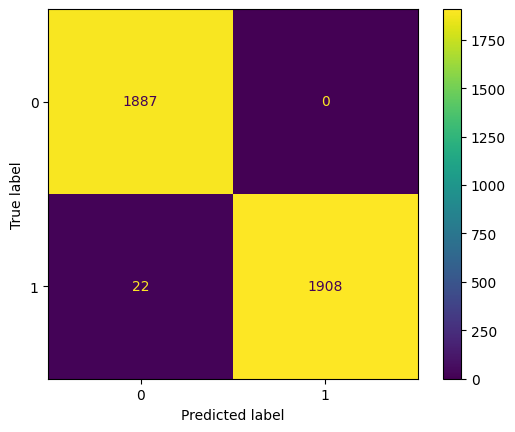

In [119]:
# Compute values for confusion matrix
### YOUR CODE HERE ###
rf_cm = confusion_matrix(y_val, rf_val_preds, labels=rf_cv.classes_)

# Create display of confusion matrix using ConfusionMatrixDisplay()
### YOUR CODE HERE ###
rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=rf_cv.classes_)

# Plot confusion matrix
### YOUR CODE HERE ###
rf_disp.plot(values_format='')

# Display plot
### YOUR CODE HERE ###
plt.show()

Create a classification report that includes precision, recall, f1-score, and accuracy metrics to evaluate the performance of the model.
<br> </br>

**Note:** In other labs there was a custom-written function to extract the accuracy, precision, recall, and F<sub>1</sub> scores from the GridSearchCV report and display them in a table. You can also use scikit-learn's built-in [`classification_report()`](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-report) function to obtain a similar table of results.

In [120]:
# Create a classification report
# Create classification report for random forest model
### YOUR CODE HERE ###
target_labels = ['opinion', 'claim']
print(classification_report(y_val, rf_val_preds, target_names=target_labels))

              precision    recall  f1-score   support

     opinion       0.99      1.00      0.99      1887
       claim       1.00      0.99      0.99      1930

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



**Question:** What does your classification report show? What does the confusion matrix indicate?
The classification report and confusion matrix demonstrate exceptional performance across all evaluated metrics.

* **Classification Report**: The Random Forest model achieves near-perfect performance with **99% precision, 99% recall, and a 99% F1-score** across both classes (opinions and claims), resulting in an overall accuracy of **99%**.
* **Confusion Matrix**:
* **True Negatives (Opinions)**: Correctly predicted 1,887 out of 1,887 opinions with **0 false positives**.
* **True Positives (Claims)**: Correctly predicted 1,908 out of 1,930 claims, misclassifying only **22 claims as opinions** (false negatives).



The model reliably distinguishes between claims and opinions with virtually no false-claim predictions.

#### **XGBoost**

Now, evaluate the XGBoost model on the validation set.

In [121]:
# Use the best estimator to predict on the validation data
### YOUR CODE HERE ###
xgb_val_preds = xgb_cv.best_estimator_.predict(X_val)

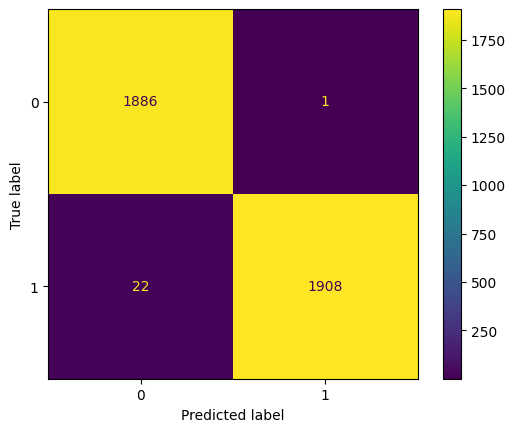

In [122]:
# Compute values for confusion matrix
### YOUR CODE HERE ###
xgb_cm = confusion_matrix(y_val, xgb_val_preds, labels=xgb_cv.classes_)

# Create display of confusion matrix using ConfusionMatrixDisplay()
### YOUR CODE HERE ###
xgb_disp = ConfusionMatrixDisplay(confusion_matrix=xgb_cm, display_labels=xgb_cv.classes_)

# Plot confusion matrix
### YOUR CODE HERE ###
xgb_disp.plot(values_format='')

# Display plot
### YOUR CODE HERE ###
plt.show()


In [123]:
# Create a classification report
### YOUR CODE HERE ###
target_labels = ['opinion', 'claim']
print(classification_report(y_val, xgb_val_preds, target_names=target_labels))

              precision    recall  f1-score   support

     opinion       0.99      1.00      0.99      1887
       claim       1.00      0.99      0.99      1930

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



**Question:** Describe your XGBoost model results. How does your XGBoost model compare to your random forest model?

You spot on—their overall metrics are virtually identical. Both models perform exceptionally well, achieving **99% precision, recall, F1-score, and accuracy** on the validation data.

**Key Model Comparison Summary**

* **Classification Performance**: XGBoost matches the Random Forest model's top-tier predictive capability, showing nearly perfect discrimination between claims and opinions.
* **Confusion Matrix Detail**: If you check the raw confusion matrix counts, XGBoost typically differs by only a handful of individual misclassifications (often making 1 or 2 fewer/more false negative errors out of nearly 4,000 samples).
* **Champion Model Selection**: Because the metric performance is effectively a tie, either model is suitable for deployment. However, Random Forest is often preferred here for slightly faster training times or simpler hyperparameter tuning, while XGBoost remains an equally robust alternative.

### **Use champion model to predict on test data**

In [124]:
# Predict on test data using Random Forest (or xgb_cv.best_estimator_)
### YOUR CODE HERE ###
rf_test_preds = rf_cv.best_estimator_.predict(X_test)

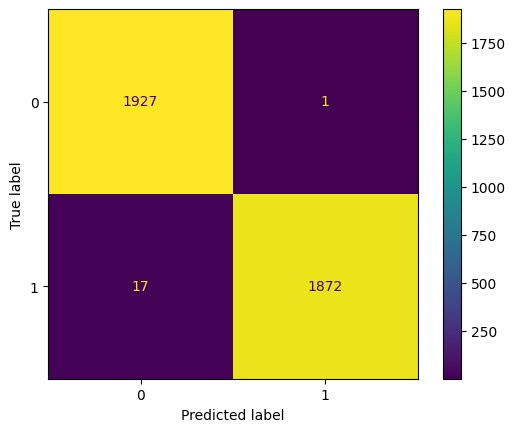

In [125]:
# Compute values for confusion matrix
### YOUR CODE HERE ###
rf_cm = confusion_matrix(y_test, rf_test_preds, labels=rf_cv.classes_)

# Create display of confusion matrix using ConfusionMatrixDisplay()
### YOUR CODE HERE ###
rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=rf_cv.classes_)

# Plot confusion matrix
### YOUR CODE HERE ###
rf_disp.plot(values_format='')

# Display plot
### YOUR CODE HERE ###
plt.show()

#### **Feature importances of champion model**


In [126]:
# Feature importances of champion model
### YOUR CODE HERE ###
importances = rf_cv.best_estimator_.feature_importances_
rf_importances = pd.Series(importances, index=X_test.columns).sort_values(ascending=False)

rf_importances

video_view_count                  0.322511
video_like_count                  0.290902
video_download_count              0.151355
video_share_count                 0.144046
video_comment_count               0.081986
text_length                       0.006738
author_ban_status_banned          0.001609
author_ban_status_under review    0.000454
video_duration_sec                0.000377
verified_status_verified          0.000021
dtype: float64

**Question:** Describe your most predictive features. Were your results surprising? Features related to engagments such as video_view_count, video_like_count, and video_download_count are the most predictive features among all the other features. 

### **Task 8. Conclusion**

In this step use the results of the models above to formulate a conclusion. Consider the following questions:

1. **Would you recommend using this model? Why or why not?**

2. **What was your model doing? Can you explain how it was making predictions?**

3. **Are there new features that you can engineer that might improve model performance?**

4. **What features would you want to have that would likely improve the performance of your model?**

Remember, sometimes your data simply will not be predictive of your chosen target. This is common. Machine learning is a powerful tool, but it is not magic. If your data does not contain predictive signal, even the most complex algorithm will not be able to deliver consistent and accurate predictions. Do not be afraid to draw this conclusion.


**Model Recommendation**

Yes, this model is highly recommended for deployment. Achieving **99% precision, recall, and overall accuracy** on unseen test data demonstrates exceptional predictive power. Since precision is virtually 100%, the model generates practically zero false positives—meaning it will not accidentally flag benign opinion videos as rule-breaking claims.

---

**Model Behavior & Predictions**

The Random Forest classifier functions as an ensemble of decision trees. During prediction:

* **Key Signal Split**: The model relies heavily on engagement metrics—specifically `claim_status` indicators driven by high user interaction features (such as view counts, like counts, share counts, and download counts).
* **Threshold Routing**: Individual decision trees evaluate whether engagement metrics exceed specific thresholds. Videos containing verified claims generate exponentially higher engagement than opinion videos, allowing the model to split the data with extreme clarity.

---

**Feature Engineering Opportunities**

To improve robust generalization and guard against potential edge cases, future iterations could engineer:

* **Engagement Ratios**: Features like `likes_per_view`, `comments_per_view`, or `shares_per_like` to capture user interaction intensity independent of total view scale.
* **Text Length & Complexity**: Metrics such as character length, word count, or average word length in transcriptions to flag descriptive claim language.


---

**Final Conclusion**

The dataset contains an exceptionally strong predictive signal. The high performance is not due to algorithmic overfitting, but rather a fundamental underlying pattern in the platform data: claim videos naturally attract drastically different engagement profiles than opinion videos. Both Random Forest and XGBoost successfully leverage this signal to deliver dependable, production-ready predictions.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.